# Analysis of the Dataset using SQL queries

Let's investigate the problem of canceled orders and answer next question:
- Which potential revenue was loosed because of cancellations;
- Which countries influenced the most the loss of the potential revenue;
- Which features can be used for cancellation prediction

In [101]:
import pandas as pd
from matplotlib.pyplot import ylabel
from matplotlib.ticker import FuncFormatter
from openpyxl.styles.builtins import total
from sqlalchemy import create_engine, text
import numpy as np
from dotenv import load_dotenv
from matplotlib.ticker import FuncFormatter
import os
import matplotlib.pyplot as plt
import seaborn as sns

In [102]:
pd.set_option('display.width', 100)
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

def sp(second_row=True):
    print('='*70)
    if second_row:
        print()
        print('='*70)

def get_info(df: pd.DataFrame):
    print("Shape:", df.shape)
    sp()
    print(df.info())
    sp()
    print(df.head())
    sp()
    print(df.describe())

In [103]:
load_dotenv()

db_host = os.getenv("DB_HOST")
db_port = os.getenv("DB_PORT")
db_name = os.getenv("DB_NAME")
db_user = os.getenv("DB_USER")
db_password = os.getenv("DB_PASSWORD")

engine = create_engine(
    f"postgresql+psycopg2://{db_user}:{db_password}@{db_host}:{db_port}/{db_name}"
)

### Plot Functions

In [104]:
def bar_plot(
    df: pd.DataFrame,
    x: str,
    y: str,
    xlabel: str = "",
    ylabel: str = "",
    title: str = "",
    suffix: str = "",
    precision: int = 0,
):
    data = df

    fig, ax = plt.subplots(figsize=(14, 7))

    sns.barplot(
        data=data,
        x=y,
        y=x,
        ax=ax,
        color='crimson'
    )

    ax.set_title(
        title,
        fontsize=18,
        pad=20,
        fontweight='bold'
    )

    ax.set_xlabel(ylabel or y.replace('_', ' ').title())
    ax.set_ylabel(xlabel or x.replace('_', ' ').title())

    ax.grid(
        axis='x',
        linestyle='--',
        alpha=0.4
    )
    sns.despine(left=True)

    if (suffix):
        ax.xaxis.set_major_formatter(
            FuncFormatter(lambda val, pos: f'{val:.0f} {suffix}')
        )

    # Value labels
    for container in ax.containers:
        labels = [
            f'{v.get_width():.{precision}f} {suffix}'
            for v in container
        ]
        ax.bar_label(
            container,
            padding=4,
            labels=labels
        )

    sns.set_theme(style="whitegrid")
    plt.tight_layout()

    plt.savefig(f'../plots/{title or (x + " VS " + y)}.png')
    plt.show()

In [105]:
def double_bar_plot(
    df: pd.DataFrame,
    x: str,
    y1: str,
    y2: str,
    title: str = "",
    xlabel: str = "",
    y1_label: str = "",
    y2_label: str = "",
    suffix: str = "",
    precision: int = 0
):
    data = df.copy()

    positions = np.arange(len(data))
    bar_height = 0.35

    fig, ax = plt.subplots(figsize=(14, 7))

    bars1 = ax.barh(
        positions - bar_height / 2,
        data[y1],
        height=bar_height,
        label=y1_label or y1,
        color="crimson"
    )

    bars2 = ax.barh(
        positions + bar_height / 2,
        data[y2],
        height=bar_height,
        label=y2_label or y2,
        color="steelblue"
    )

    ax.set_yticks(positions)
    ax.set_yticklabels(data[x])

    ax.set_title(title, fontsize=18, pad=20, fontweight="bold")
    ax.set_xlabel(xlabel or "Value")
    ax.set_ylabel(x.replace("_", " ").title())

    ax.grid(axis="x", linestyle="--", alpha=0.4)
    ax.legend()

    if (suffix):
        ax.xaxis.set_major_formatter(
            FuncFormatter(lambda val, pos: f'{val:.0f} {suffix}')
        )

    for bars in [bars1, bars2]:
        labels = [
            f"{bar.get_width():.{precision}f} {suffix}"
            for bar in bars
        ]
        ax.bar_label(bars, labels=labels, padding=4)

    sns.despine(left=True)
    sns.set_theme(style="whitegrid")
    ax.invert_yaxis()
    plt.tight_layout()

    plt.savefig(f'../plots/{title or (x + " VS " + y1 + " and " + y2)}.png')
    plt.show()

In [106]:
def vertical_bar_plot(
    df,
    x,
    y,
    xlabel="",
    ylabel="",
    title="",
    suffix="",
    precision=0,
    xlabel_angle=0
):
    sns.set_theme(style="whitegrid")

    fig, ax = plt.subplots(figsize=(14, 7))

    sns.barplot(
        data=df,
        x=x,
        y=y,
        ax=ax,
        color="crimson"
    )

    ax.set_title(
        title,
        fontsize=18,
        pad=20,
        fontweight="bold"
    )

    ax.set_xlabel(
        xlabel or x.replace("_", " ").title()
    )

    ax.set_ylabel(
        ylabel or y.replace("_", " ").title()
    )

    ax.grid(
        axis="y",
        linestyle="--",
        alpha=0.4
    )

    sns.despine()

    # Rotate labels if categories are long
    plt.xticks(
        rotation=xlabel_angle,
        ha="right"
    )

    if suffix:
        ax.yaxis.set_major_formatter(
            FuncFormatter(
                lambda val, pos:
                f"{val:.{precision}f}{suffix}"
            )
        )

    # Value labels
    for container in ax.containers:
        labels = [
            f"{v.get_height():.{precision}f}{suffix}"
            for v in container
        ]

        ax.bar_label(
            container,
            labels=labels,
            padding=3
        )

    plt.tight_layout()

    plt.savefig(f'../plots/{title or (x + " VS " + y)}.png')
    plt.show()

In [107]:
def hist_plot(
    df,
    column,
    bins=30,
    title="",
    xlabel="",
    ylabel="Count",
    color="crimson"
):
    sns.set_theme(style="whitegrid")

    fig, ax = plt.subplots(figsize=(14, 7))

    sns.histplot(
        data=df,
        x=column,
        bins=bins,
        color=color,
        edgecolor="white",
        linewidth=1,
        ax=ax
    )

    ax.set_title(
        title or column.replace("_", " ").title(),
        fontsize=18,
        pad=20,
        fontweight="bold"
    )

    ax.set_xlabel(
        xlabel or column.replace("_", " ").title()
    )

    ax.set_ylabel(ylabel)

    ax.grid(
        axis="y",
        linestyle="--",
        alpha=0.4
    )

    sns.despine()

    plt.tight_layout()

    plt.savefig(f'../plots/{title or (column + ' Distribution')}.png')
    plt.show()

### Analysis of Order Cancellation over Countries

In [108]:
query_canceled_total_loss = """
    SELECT SUM(revenue)
    FROM sales
    WHERE
        canceled = true
"""

canceled_total_loss = pd.read_sql(query_canceled_total_loss, engine)
print(round(canceled_total_loss.iloc[0, 0]), '£ is a loss of a potential income caused by order cancellation.', sep='')

896812£ is a loss of a potential income caused by order cancellation.


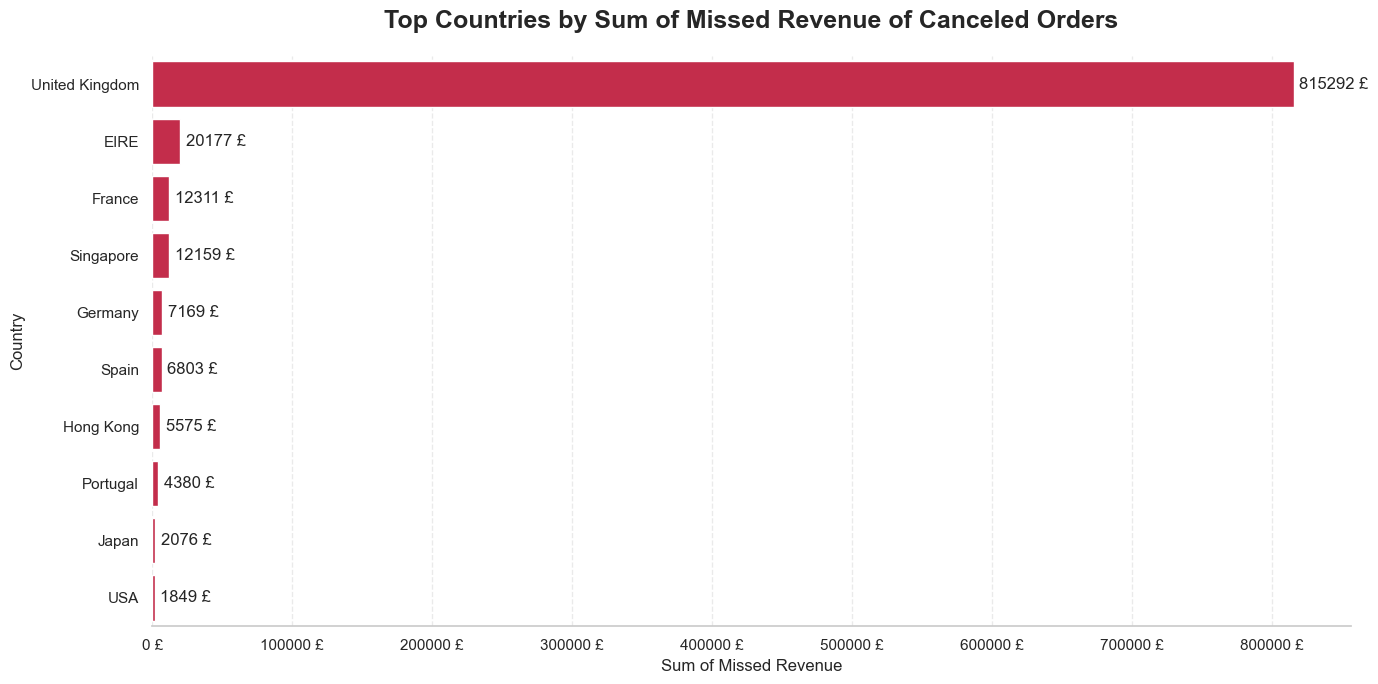

In [109]:
query_country_canceled_revenue_sum = """
    SELECT country, SUM(revenue) as sum
    FROM sales
    WHERE canceled = true
    GROUP BY country
    ORDER BY sum DESC
    LIMIT 10
"""
df_country_canceled_revenue_sum = pd.read_sql(query_country_canceled_revenue_sum, engine)
bar_plot(df_country_canceled_revenue_sum, 'country', 'sum', title="Top Countries by Sum of Missed Revenue of Canceled Orders", ylabel="Sum of Missed Revenue", suffix='£')

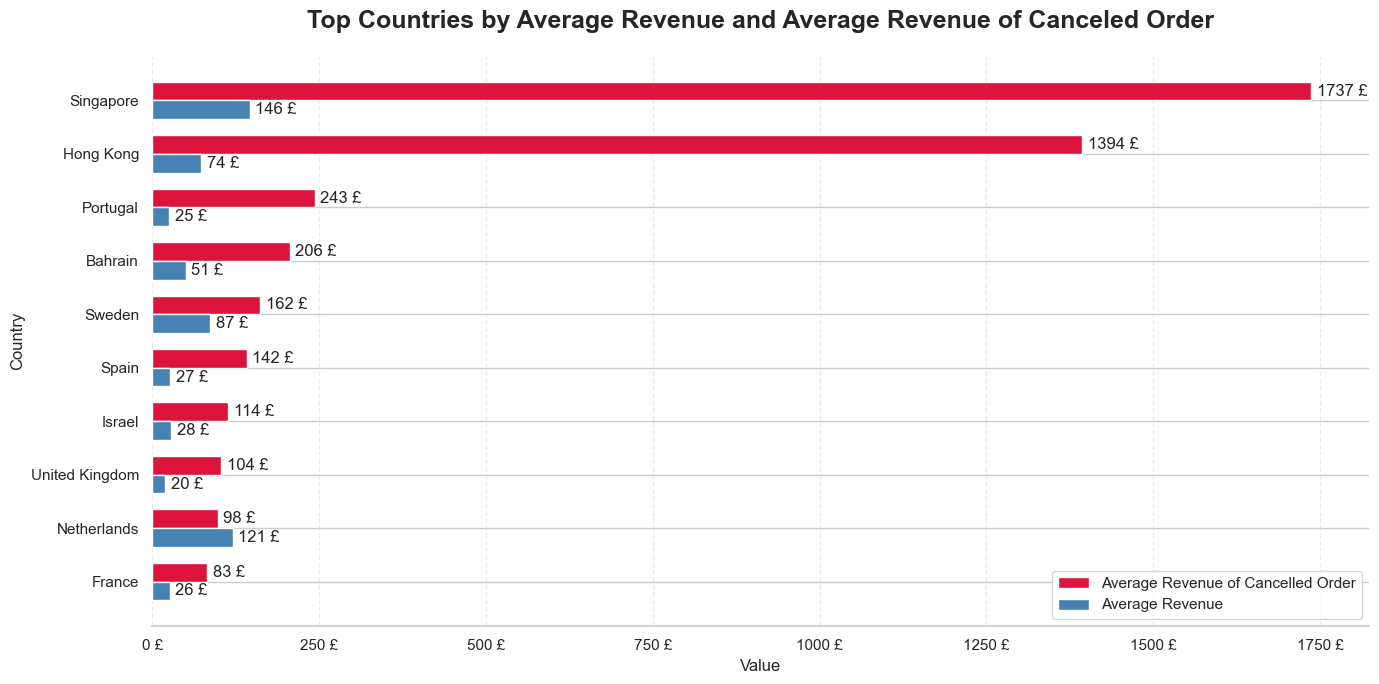

In [110]:
query_country_canceled_revenue_avg = """
    SELECT
        country,
        AVG(revenue) FILTER (WHERE canceled = true) as avg_canceled,
        AVG(revenue) as avg
    FROM sales
    GROUP BY country
    HAVING COUNT(*) FILTER (WHERE canceled = true) > 0
    ORDER BY avg_canceled DESC
    LIMIT 10
"""
df_country_canceled_revenue_avg = pd.read_sql(query_country_canceled_revenue_avg, engine)
double_bar_plot(df_country_canceled_revenue_avg, 'country', 'avg_canceled', 'avg', title="Top Countries by Average Revenue and Average Revenue of Canceled Order", y1_label="Average Revenue of Cancelled Order", y2_label='Average Revenue', suffix='£')

### Conclusion: Impact on the Revenue
As we can see, almost a 900`000£ of potential revenue was lost because of order cancellation.

90% of the loss go to the United Kingdom, since 91% of orders of customers if United Kingdom. But some countries tend to have orders higher revenue for order that will be canceled. That is why training predictive model could help determing and prevent such cases.

### Search for Model Training Features
For training a model it is required to determine which features will be used. For this given features will be inspected for patterns of canceled orders.

#### User Identification

##### Customer ID

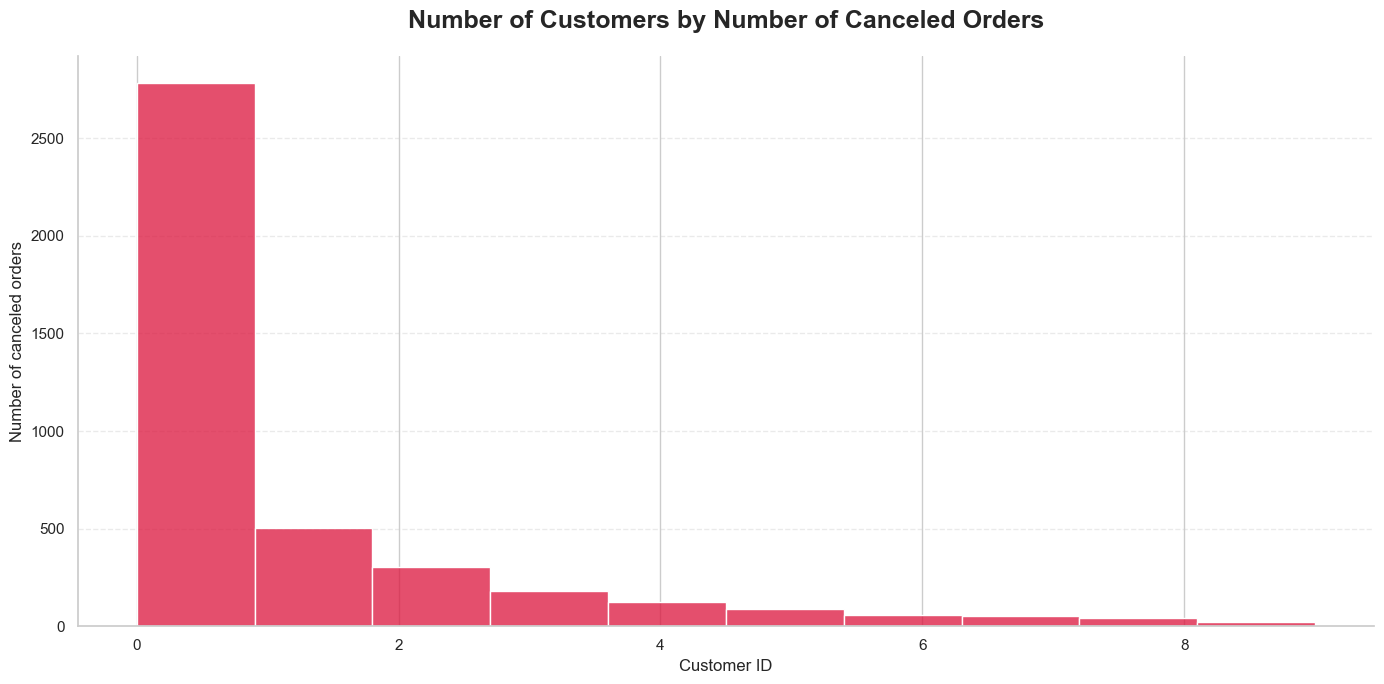

In [111]:
query_canceled_customerid = """
    SELECT customerid::text, count
    FROM (SELECT customerid,
                 COUNT(*) FILTER (WHERE canceled = true) AS  count
          FROM sales
          GROUP BY customerid)
    WHERE count < 10
    ORDER BY count DESC
"""

df_canceled_customerid = pd.read_sql(query_canceled_customerid, engine)
hist_plot(df_canceled_customerid, 'count', xlabel='Customer ID', title='Number of Customers by Number of Canceled Orders', ylabel='Number of canceled orders', bins=10)

##### Invoice Number

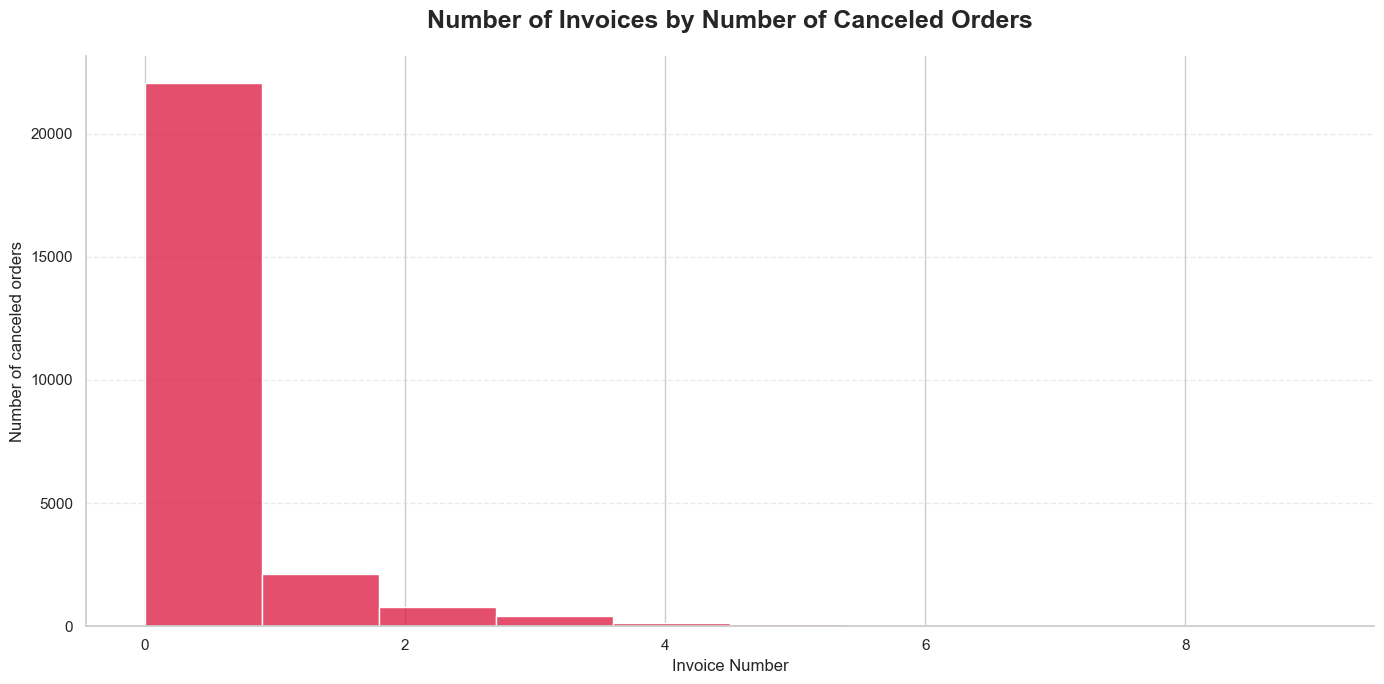

In [112]:
query_canceled_invoiceno = """
   SELECT invoiceno::text, count
   FROM (SELECT invoiceno,
                COUNT(*) FILTER (WHERE canceled = true) AS  count
         FROM sales
         GROUP BY invoiceno)
   WHERE count < 10
   ORDER BY count DESC
"""

df_canceled_invoiceno = pd.read_sql(query_canceled_invoiceno, engine)
hist_plot(df_canceled_invoiceno, 'count', title='Number of Invoices by Number of Canceled Orders', xlabel='Invoice Number', ylabel='Number of canceled orders', bins=10)

##### Country

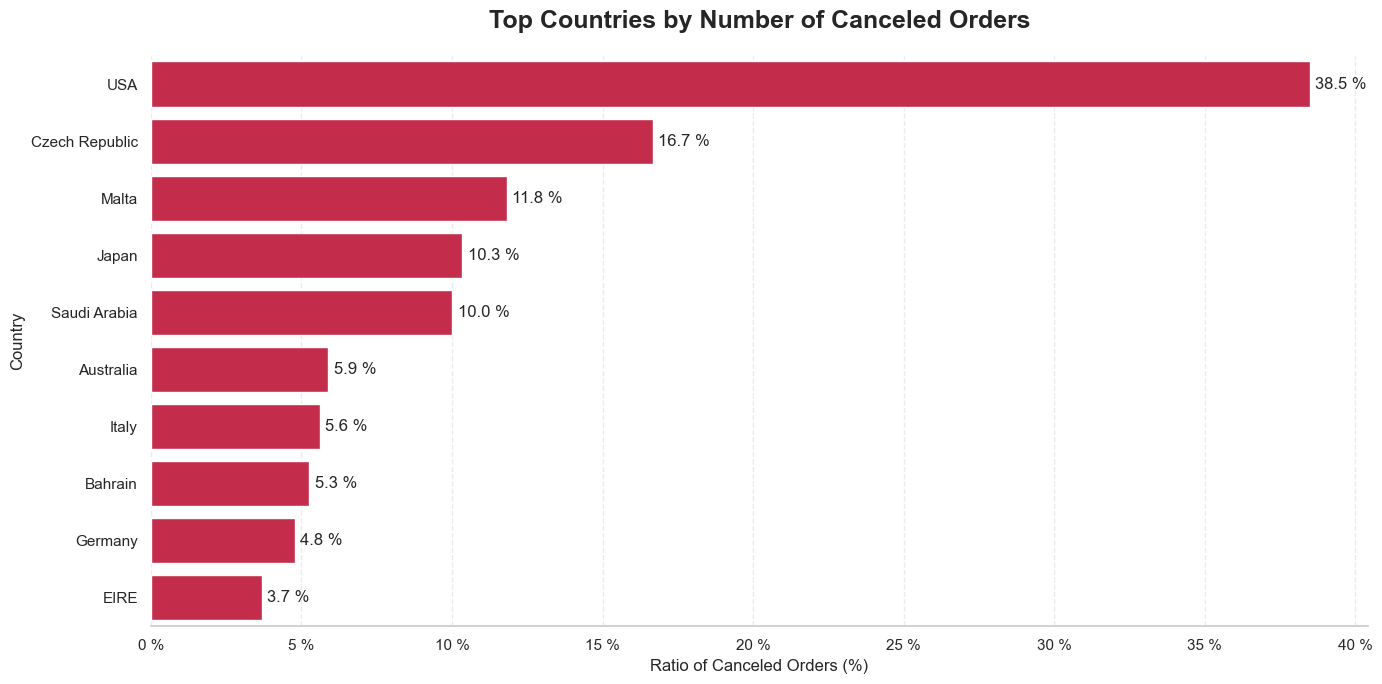

In [113]:
query_country_cancellation_ratio = """
    SELECT
        country,
        ROUND (
            100.0 * canceled / total,
            2
        ) AS ratio
    FROM (
        SELECT
            country,
            COUNT (*) AS total,
            COUNT (*) FILTER (WHERE canceled = true) AS canceled
        FROM
            sales
        GROUP BY
            country
    )
    ORDER BY
        ratio DESC
    LIMIT 10

"""

df_country_cancellation_ratio = pd.read_sql(query_country_cancellation_ratio, engine)
bar_plot(df_country_cancellation_ratio, 'country', 'ratio', title="Top Countries by Number of Canceled Orders", ylabel="Ratio of Canceled Orders (%)", suffix='%', precision=1)

##### Conclusion: User Identification
For identification of the user it is possible to take `invoiceno` or `customerid`. Since it seems adding both feature may distract the model during training, it was decided to take only `customerid` feature, since it has less bias distribution. The feature `country` will be taken also, since it demostrated to be a good indicator.

#### Date - Time
Let's analyze how different time periods influence the order cancellation:
- Season of the year
- Month of the year
- Day of the month
- Day of the month
- Hour of the day
- Minute of the hour


##### Season of the Year

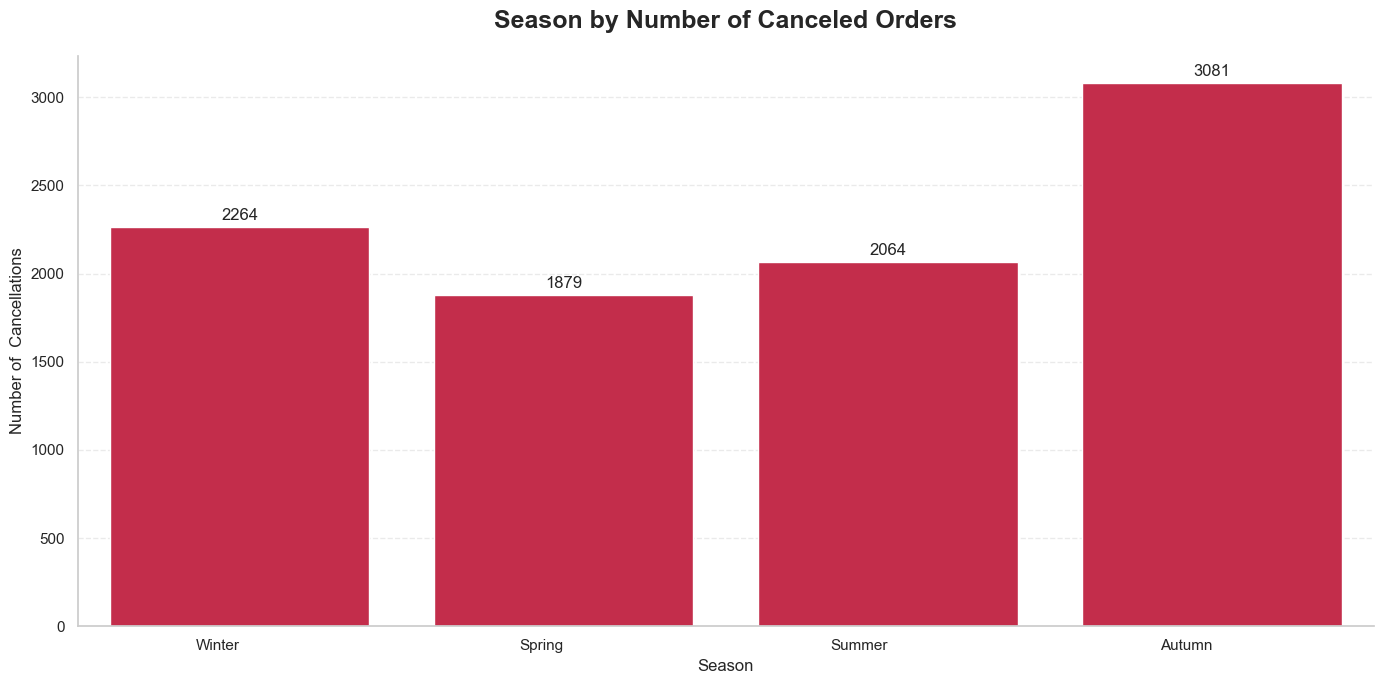

In [114]:
query_season_check = """
    SELECT
        season,
        season_int,
        COUNT(*) FILTER (WHERE canceled = true) AS cancellations
    FROM (
        SELECT
            canceled,
            CASE
                WHEN EXTRACT(MONTH FROM invoicedate) IN (12, 1, 2) THEN 'Winter'
                WHEN EXTRACT(MONTH FROM invoicedate) IN (3, 4, 5) THEN 'Spring'
                WHEN EXTRACT(MONTH FROM invoicedate) IN (6, 7, 8) THEN 'Summer'
                WHEN EXTRACT(MONTH FROM invoicedate) IN (9, 10, 11) THEN 'Autumn'
            END AS season,
            CASE
                WHEN EXTRACT(MONTH FROM invoicedate) IN (12, 1, 2) THEN 1
                WHEN EXTRACT(MONTH FROM invoicedate) IN (3, 4, 5) THEN 2
                WHEN EXTRACT(MONTH FROM invoicedate) IN (6, 7, 8) THEN 3
                WHEN EXTRACT(MONTH FROM invoicedate) IN (9, 10, 11) THEN 4
            END AS season_int
        FROM sales
    )
    GROUP BY
        season_int, season
    ORDER BY
        season_int

"""

df_season_check = pd.read_sql(query_season_check, engine)
vertical_bar_plot(df_season_check, 'season', 'cancellations', title='Season by Number of Canceled Orders', ylabel='Number of  Cancellations')

##### Month of the Year

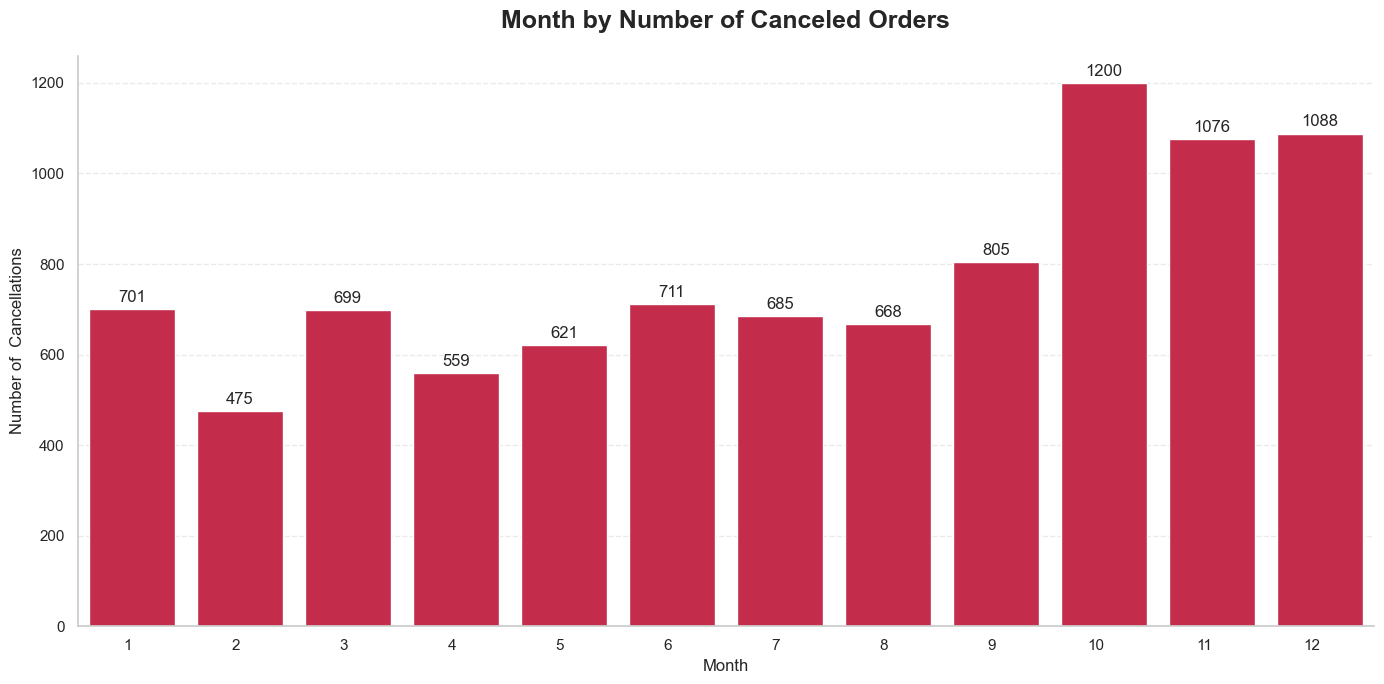

In [115]:
query_month_check = """
    SELECT
        month,
        COUNT(*) FILTER (WHERE canceled = true) AS cancellations
    FROM (
        SELECT
            EXTRACT(MONTH FROM invoicedate)::int AS month,
            canceled
        FROM sales
    )
    GROUP BY
        month
    ORDER BY
        month

"""

df_month_check = pd.read_sql(query_month_check, engine)
vertical_bar_plot(df_month_check, 'month', 'cancellations', title='Month by Number of Canceled Orders',  ylabel='Number of  Cancellations')

##### Day of the Month

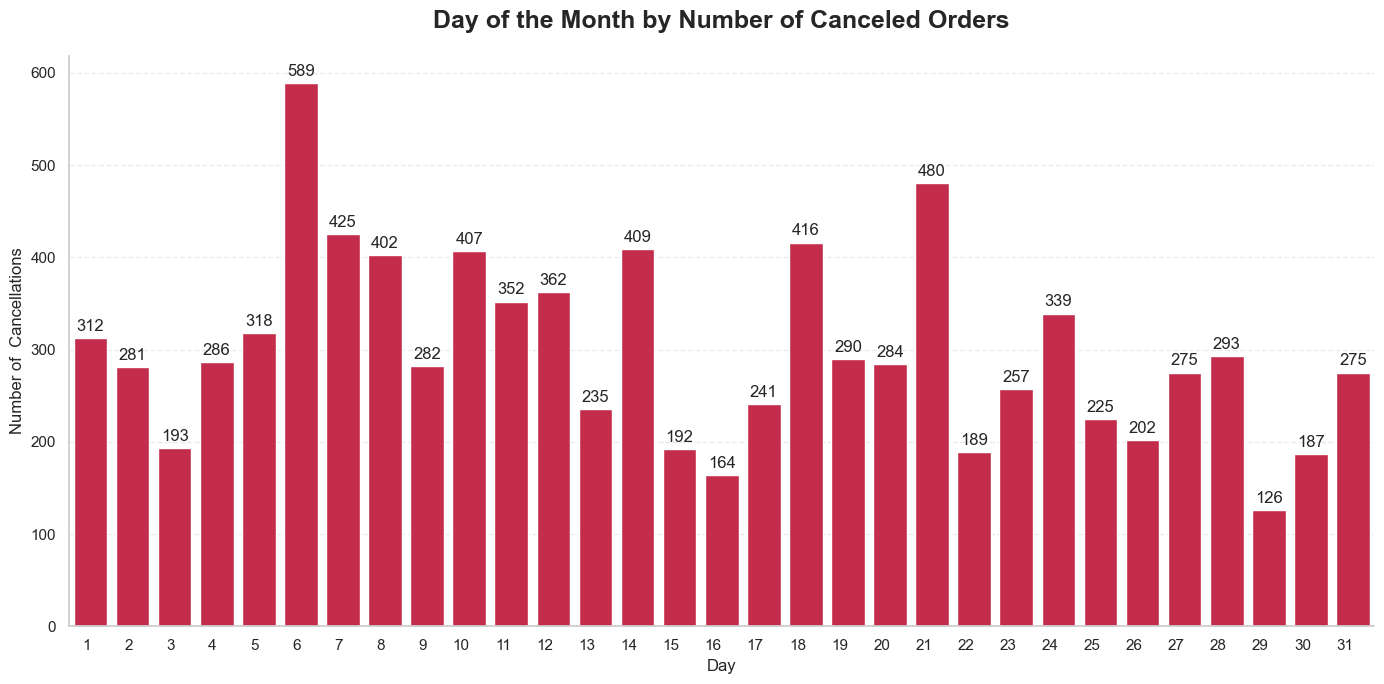

In [116]:
query_day_month_check = """
    SELECT
        day,
        COUNT(*) FILTER (WHERE canceled = true) AS cancellations
    FROM (
        SELECT
            EXTRACT(DAY FROM invoicedate)::int AS day,
            canceled
        FROM sales
    )
    GROUP BY
        day

"""

df_day_month_check = pd.read_sql(query_day_month_check, engine)
vertical_bar_plot(df_day_month_check, 'day', 'cancellations', title='Day of the Month by Number of Canceled Orders', ylabel='Number of  Cancellations')

##### Day of the Week

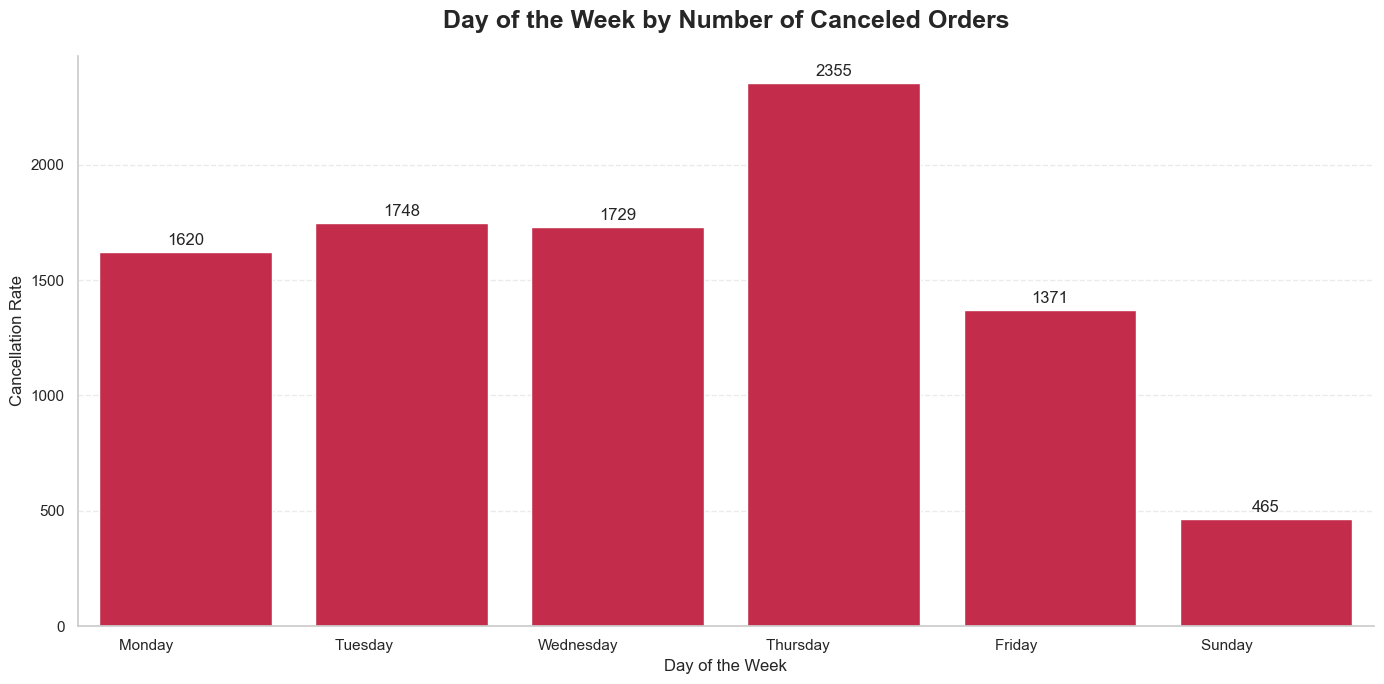

In [117]:
query_day_week_check = """
    SELECT
        dow_int,
        dow,
        COUNT(*) FILTER (WHERE canceled = true) AS cancellations
    FROM (
        SELECT
            EXTRACT(ISODOW FROM invoicedate) AS dow_int,
            TO_CHAR(invoicedate, 'Day') AS dow,
            canceled
        FROM sales
    )
    GROUP BY
        dow_int, dow
    ORDER BY
        dow_int

"""

df_day_week_check = pd.read_sql(query_day_week_check, engine)
vertical_bar_plot(df_day_week_check, 'dow', 'cancellations', title='Day of the Week by Number of Canceled Orders', xlabel='Day of the Week', ylabel='Cancellation Rate')

##### Hour of the Day

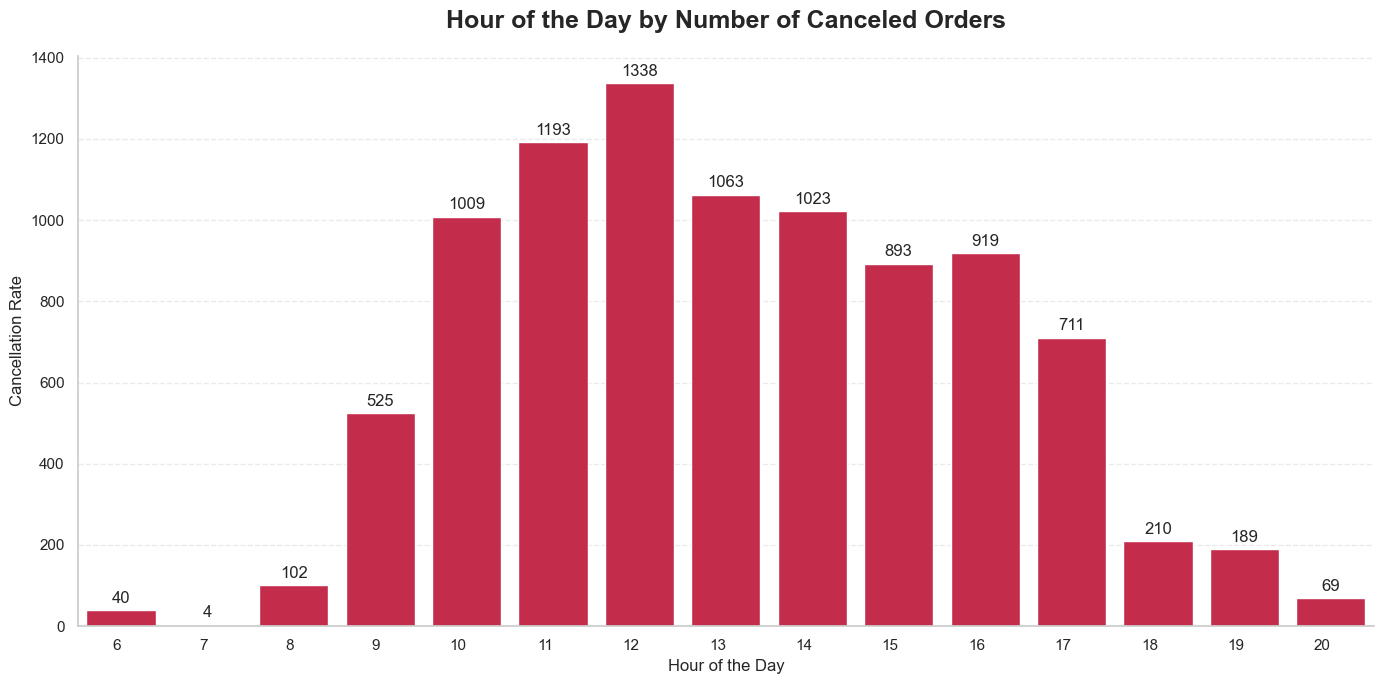

In [118]:
query_hour_day_check = """
    SELECT
        hour,
        COUNT(*) FILTER (WHERE canceled = true) AS cancellations
    FROM (
        SELECT
            EXTRACT(HOUR FROM invoicedate)::int AS hour,
            canceled
        FROM sales
    )
    GROUP BY
        hour
    ORDER BY
        hour

"""

df_hour_day_check = pd.read_sql(query_hour_day_check, engine)
vertical_bar_plot(df_hour_day_check, 'hour', 'cancellations', title='Hour of the Day by Number of Canceled Orders', xlabel='Hour of the Day', ylabel='Cancellation Rate')

##### Minute of the Hour

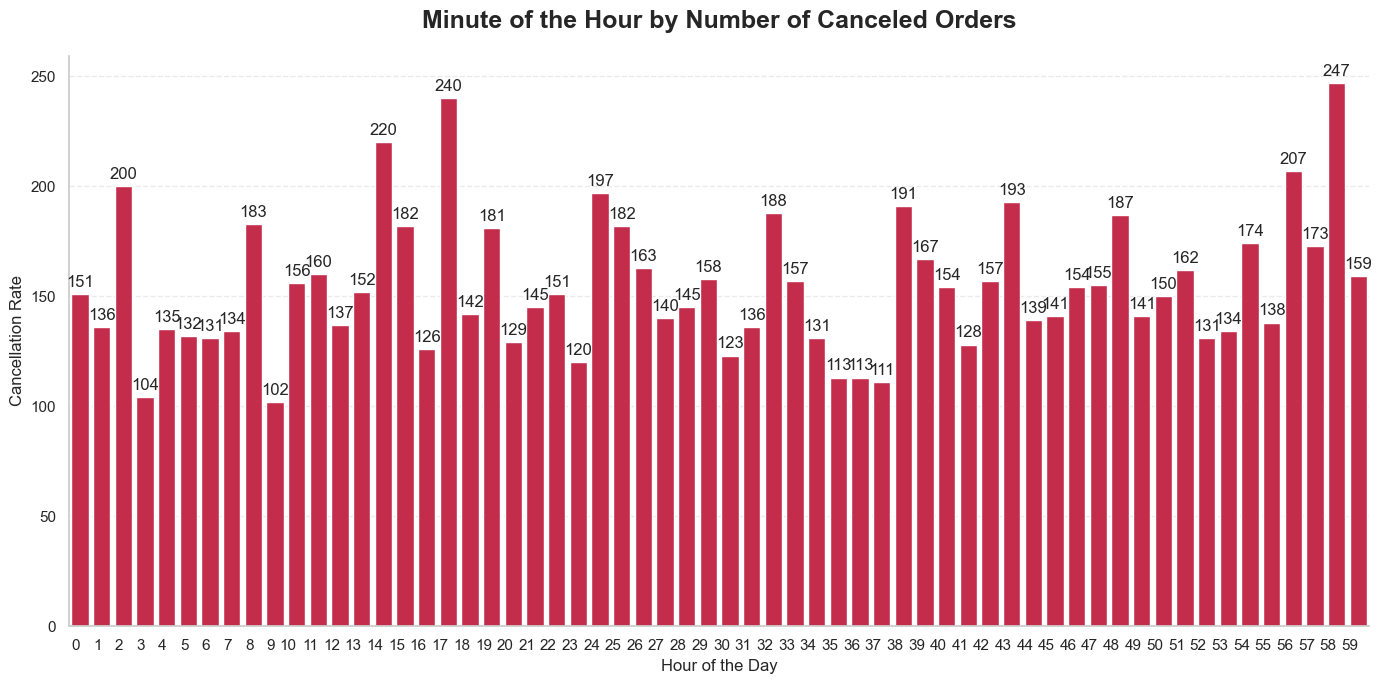

In [119]:
query_minute_hour_check = """
    SELECT
        minute,
        COUNT(*) FILTER (WHERE canceled = true) AS cancellations
    FROM (
        SELECT
            EXTRACT(MINUTE FROM invoicedate)::int AS minute,
            canceled
        FROM sales
    )
    GROUP BY
        minute
    ORDER BY
        minute

"""

df_minute_hour_check = pd.read_sql(query_minute_hour_check, engine)
vertical_bar_plot(df_minute_hour_check, 'minute', 'cancellations', title='Minute of the Hour by Number of Canceled Orders', xlabel='Hour of the Day', ylabel='Cancellation Rate')

##### Conclusion: Date - Time
After analyzing different combinations of period of time and date, it was decided to take the `month`, `weekday` and `hour` features. Both of them demonstrate the most signs of normal distribution, while others demonstrate uniform distribution.

#### Item Identification

##### Stock Code

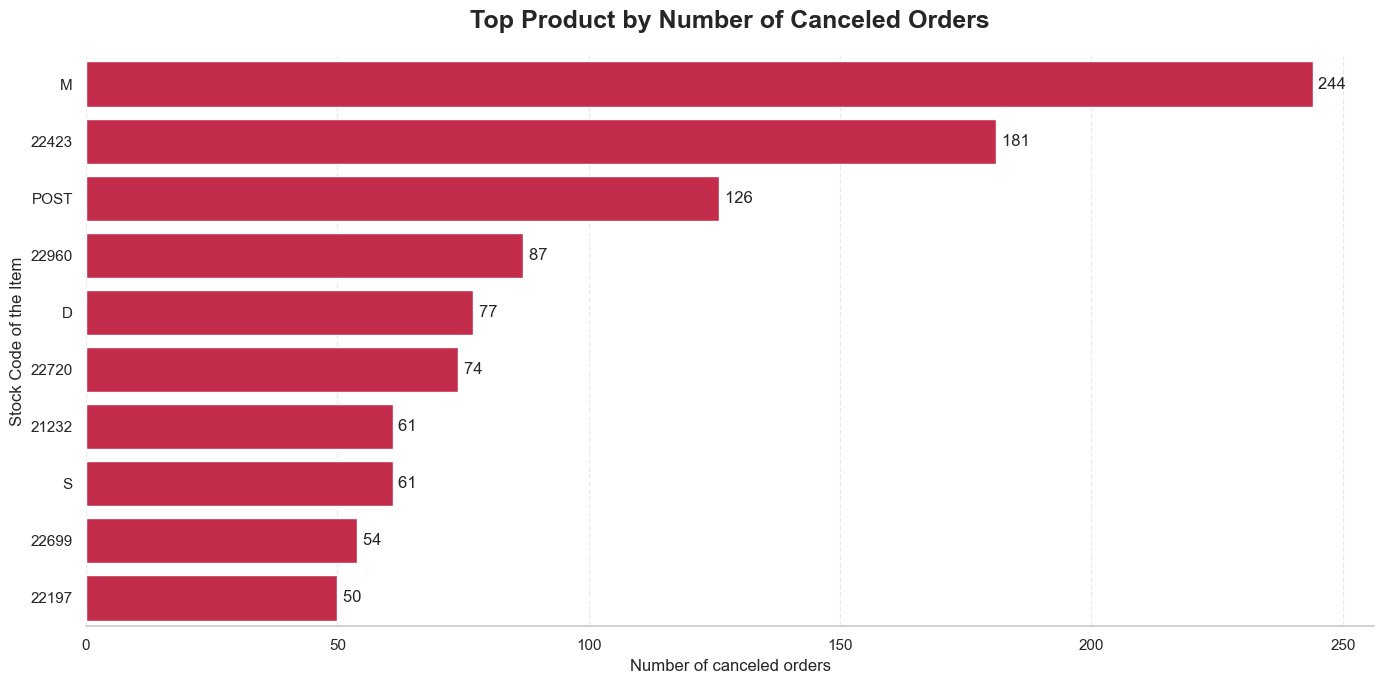

In [120]:
query_canceled_stockcode = """
    SELECT
        stockcode,
        COUNT(*) FILTER (WHERE canceled = true) AS  count
    FROM sales
    GROUP BY stockcode
    ORDER BY count DESC
    LIMIT 10
"""

df_canceled_stockcode = pd.read_sql(query_canceled_stockcode, engine)
bar_plot(df_canceled_stockcode, 'stockcode', 'count', title='Top Product by Number of Canceled Orders', xlabel='Stock Code of the Item', ylabel='Number of canceled orders')

##### Conclusion: Item Identification
For identification of the item it was decided to use the `stockcode`. Since `description` consists unstructured and large text, and it was planned to use simple model, it was decided to not use `description` as a feature.

#### Financial Indicators

##### Unit Price

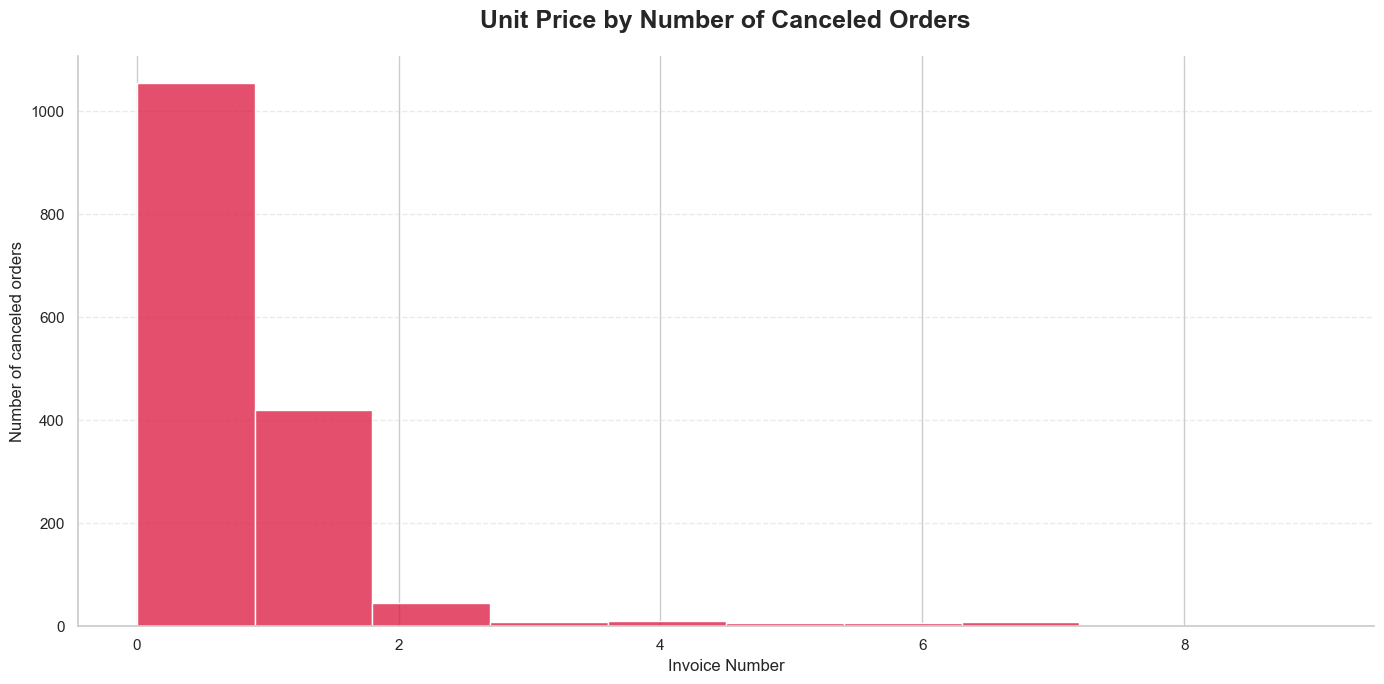

In [121]:
query_canceled_unitprice = """
    SELECT
        unitprice::text,
        count
    FROM (
        SELECT
            unitprice,
            COUNT(*) FILTER (WHERE canceled = true) AS  count
        FROM sales
        GROUP BY unitprice
        )
    WHERE count < 10
    ORDER BY count DESC
"""

df_canceled_unitprice = pd.read_sql(query_canceled_unitprice, engine)
hist_plot(df_canceled_unitprice, 'count', xlabel='Invoice Number', title='Unit Price by Number of Canceled Orders', ylabel='Number of canceled orders', bins=10)

##### Quantity

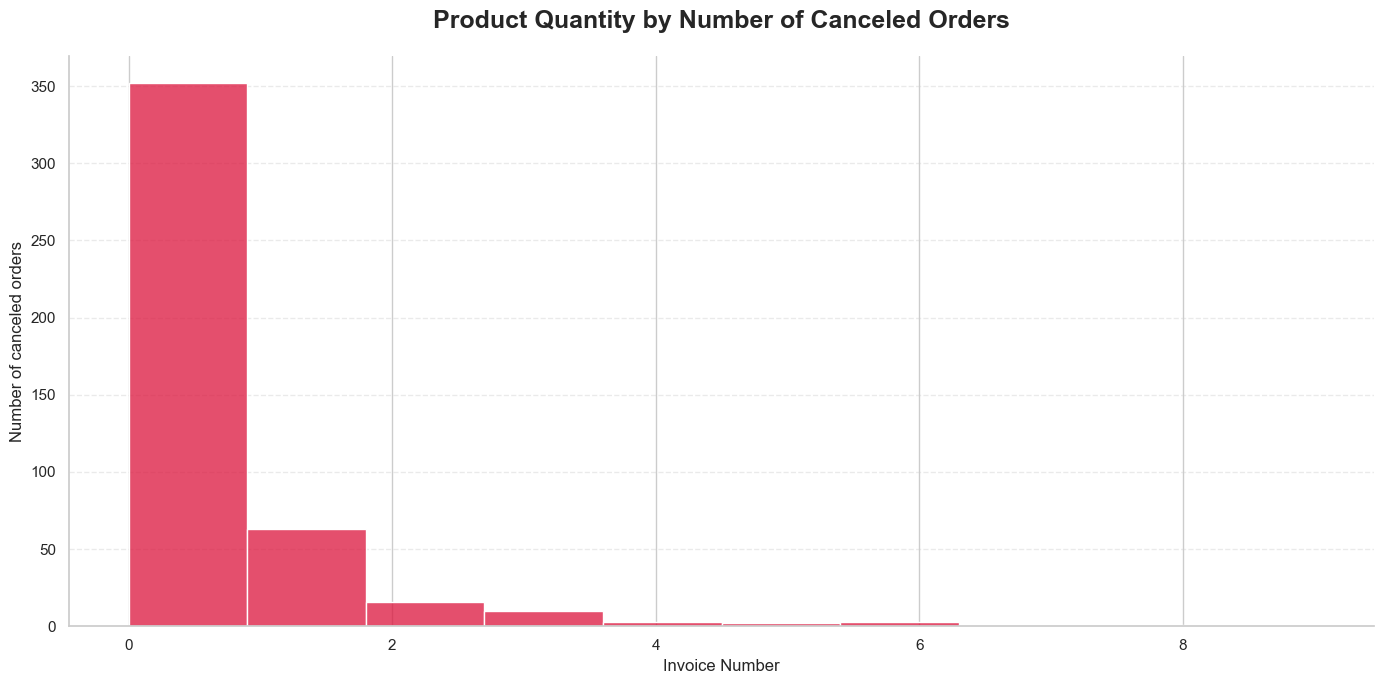

In [122]:
query_canceled_quantity = """
    SELECT
        quantity::text,
        count
    FROM (
        SELECT
            quantity,
            COUNT(*) FILTER (WHERE canceled = true) AS  count
        FROM sales
        GROUP BY quantity
        )
    WHERE count < 10
    ORDER BY count DESC
"""

df_canceled_quantity = pd.read_sql(query_canceled_quantity, engine)
hist_plot(df_canceled_quantity, 'count', xlabel='Invoice Number', title='Product Quantity by Number of Canceled Orders', ylabel='Number of canceled orders', bins=10)

##### Revenue

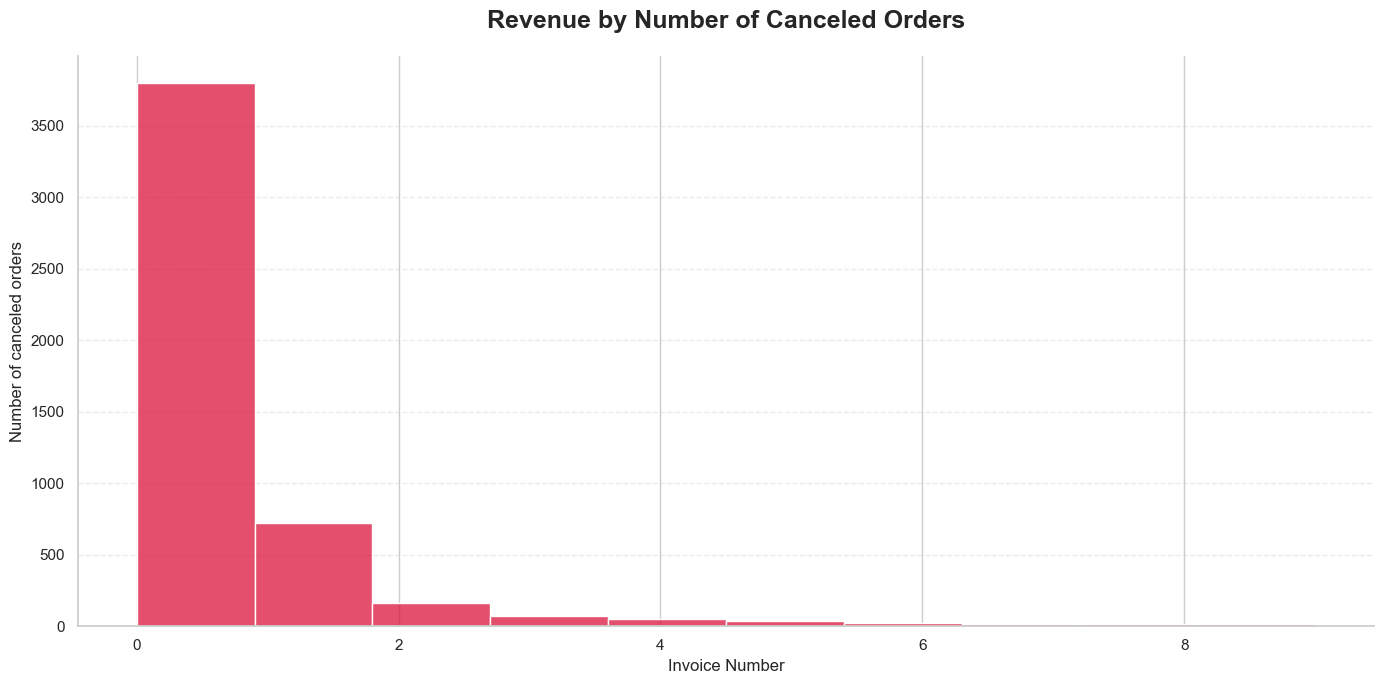

In [123]:
query_canceled_revenue = """
    SELECT
        revenue::text,
        count
    FROM (
        SELECT
            revenue,
            COUNT(*) FILTER (WHERE canceled = true) AS  count
        FROM sales
        GROUP BY revenue
        )
    WHERE count < 10
    ORDER BY count DESC
"""

df_canceled_revenue = pd.read_sql(query_canceled_revenue, engine)
hist_plot(df_canceled_revenue, 'count', xlabel='Invoice Number', title='Revenue by Number of Canceled Orders', ylabel='Number of canceled orders', bins=10)

##### Conclusion: Financial Indicators
`unitprice` and `quantity` have the same distribution and bring unique information, it was decided to use it for training the model. Since `revenue` has similar distribution it was decided to use it also.

### Conclusion: Search for Model Training Features
All provided features were presented with the graph. According to that it is possible to make a conclusion, which features should be taken for model training or for creating new features.

#### The List of Features
- customerid
- country
- month
- weekday
- hour
- unitprice
- quantity
- revenue
- stockcode
- canceled (target)